In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ks_test_results.csv", sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   n               27 non-null     int64  
 1   error           27 non-null     float64
 2   stat_diff       27 non-null     float64
 3   test_reduction  27 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 992.0 bytes


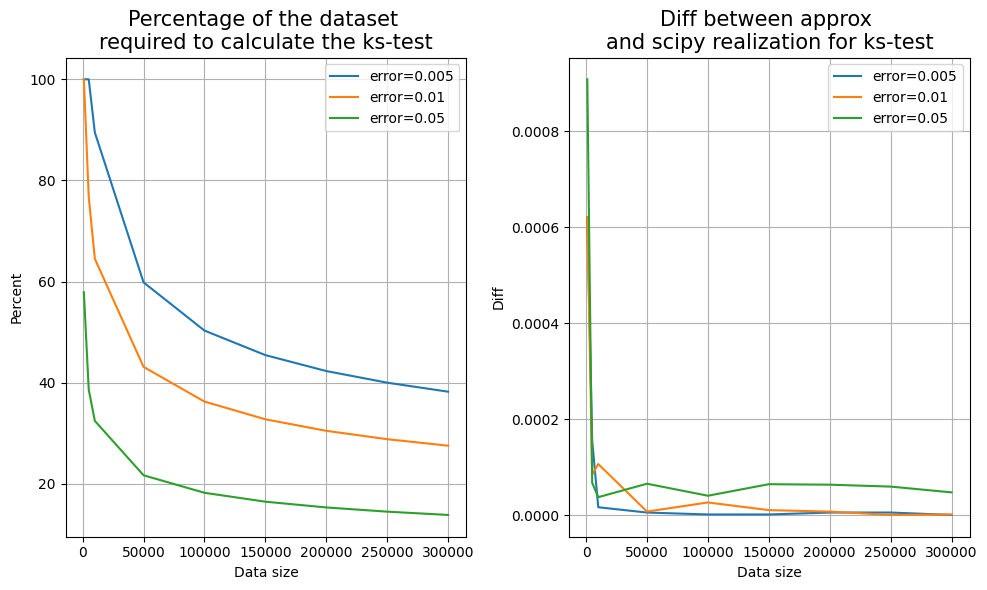

In [14]:
figure = plt.figure(figsize=(10, 6))
axs = figure.subplots(1, 2)

for error, data in df.groupby(by='error'):
    x = data['n']

    axs[0].plot(x, 100 - data['test_reduction'], label=f"error={error}")
    axs[0].legend()
    axs[0].grid()
    axs[0].set_ylabel("Percent")
    axs[0].set_xlabel("Data size")
    axs[0].set_title("Percentage of the dataset \nrequired to calculate the ks-test", fontsize=15)

    axs[1].plot(x, data['stat_diff'], label=f"error={error}")
    axs[1].legend()
    axs[1].grid()
    axs[1].set_ylabel("Diff")
    axs[1].set_xlabel("Data size")
    axs[1].set_title("Diff between approx \nand scipy realization for ks-test", fontsize=15)

plt.tight_layout()
plt.show()